In [4]:
!pip install pantab

   ---------------------------------------- 0.0/60.4 MB ? eta -:--:--
    --------------------------------------- 1.0/60.4 MB 46.2 MB/s eta 0:00:02
   - -------------------------------------- 2.9/60.4 MB 6.7 MB/s eta 0:00:09
   -- ------------------------------------- 4.2/60.4 MB 6.8 MB/s eta 0:00:09
   --- ------------------------------------ 5.2/60.4 MB 6.5 MB/s eta 0:00:09
   ---- ----------------------------------- 6.3/60.4 MB 6.3 MB/s eta 0:00:09
   ---- ----------------------------------- 7.3/60.4 MB 5.8 MB/s eta 0:00:10
   ----- ---------------------------------- 8.4/60.4 MB 5.7 MB/s eta 0:00:10
   ------ --------------------------------- 9.4/60.4 MB 5.7 MB/s eta 0:00:09
   ------ --------------------------------- 10.5/60.4 MB 5.7 MB/s eta 0:00:09
   ------- -------------------------------- 11.5/60.4 MB 5.7 MB/s eta 0:00:09
   -------- ------------------------------- 12.6/60.4 MB 5.7 MB/s eta 0:00:09
   --------- ------------------------------ 14.7/60.4 MB 5.6 MB/s eta 0:00:09
 

In [1]:
import pandas as pd
df = pd.read_parquet('V2_merge.parquet', engine='fastparquet')
# 코어회원, 플러스회원  

In [2]:
df

,t_dat,customer_id,article_id,price,sales_channel_id,FN,Active,club_member_status,fashion_news_frequency,age,...,product_group_name,graphical_appearance_name,colour_group_name,perceived_colour_value_name,perceived_colour_master_name,department_name,index_name,index_group_name,section_name,garment_group_name
0,2018-09-20,2,663713001,29.990000,2,0,0,ACTIVE,NONE,24,...,Underwear,Solid,Black,Dark,Black,Expressive Lingerie,Lingeries/Tights,Ladieswear,Womens Lingerie,"Under-, Nightwear"
1,2018-09-20,2,541518023,17.990000,2,0,0,ACTIVE,NONE,24,...,Underwear,Solid,Light Pink,Dusty Light,Pink,Casual Lingerie,Lingeries/Tights,Ladieswear,Womens Lingerie,"Under-, Nightwear"
2,2018-09-20,7,505221004,8.990000,2,1,1,ACTIVE,Regularly,32,...,Garment Upper body,Melange,Pink,Medium Dusty,Pink,Tops Knitwear DS,Divided,Divided,Divided Selected,Knitwear
3,2018-09-20,7,685687003,9.990000,2,1,1,ACTIVE,Regularly,32,...,Garment Upper body,Melange,Pink,Medium,Pink,Campaigns,Ladieswear,Ladieswear,Womens Everyday Collection,Special Offers
4,2018-09-20,7,685687004,9.990000,2,1,1,ACTIVE,Regularly,32,...,Garment Upper body,Melange,Dark Green,Dark,Green,Campaigns,Ladieswear,Ladieswear,Womens Everyday Collection,Special Offers
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31097418,2020-09-22,1361247,918522001,24.990000,2,1,1,ACTIVE,Regularly,30,...,Garment Upper body,Solid,Off White,Light,White,Knitwear,Ladieswear,Ladieswear,Womens Everyday Collection,Knitwear
31097419,2020-09-22,1361247,918485001,39.990002,2,1,1,ACTIVE,Regularly,30,...,Garment Upper body,Solid,Light Beige,Dusty Light,Beige,Blouse & Dress,Ladieswear,Ladieswear,Womens Trend,Blouses
31097420,2020-09-22,1362025,918325001,25.490000,1,0,0,ACTIVE,NONE,67,...,Accessories,Application/3D,Black,Dark,Black,Bags,Ladies Accessories,Ladieswear,Womens Big accessories,Accessories
31097421,2020-09-22,1362050,833459002,3.990000,1,1,1,ACTIVE,Regularly,21,...,Accessories,Solid,Silver,Light,Metal,Jewellery,Ladies Accessories,Ladieswear,Womens Small accessories,Accessories


In [3]:
# 1. RFM 지표 계산
df['t_dat'] = pd.to_datetime(df['t_dat'])
snapshot_date = df['t_dat'].max() + pd.Timedelta(days=1)

rfm = df.groupby('customer_id').agg(
    Recency=('t_dat', lambda x: (snapshot_date - x.max()).days),
    Frequency=('t_dat', 'nunique'),
    Monetary=('price', 'sum')
).reset_index()

In [3]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# 1. 분석에 사용할 컬럼 추출
rfm_features = rfm[['Recency', 'Frequency', 'Monetary']]

# 2. 데이터 스케일링 (단위를 일정하게 맞춤)
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_features)

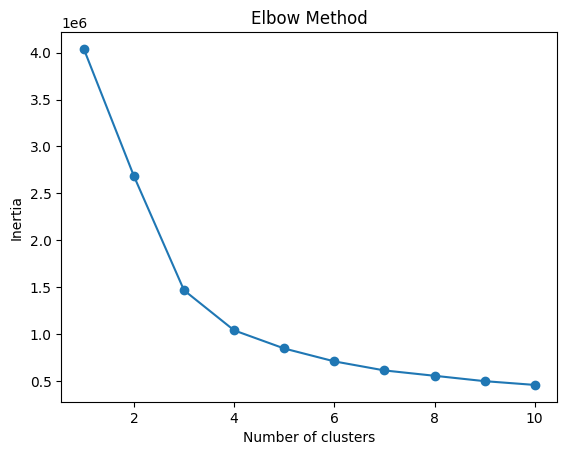

In [4]:
import matplotlib.pyplot as plt

inertia = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(1, 11), inertia, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.show()

In [5]:
# k=3으로 학습
kmeans = KMeans(n_clusters=3, init='k-means++', random_state=42)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

# 각 클러스터별 RFM 평균값 확인
print(rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean())

            Recency  Frequency     Monetary
Cluster                                    
0        106.538808   6.228271   316.192428
1        515.317107   1.824957    99.403249
2         38.242366  31.716893  2184.874913


In [6]:
# 통계적 신뢰도 (중심극한정리)
# # Silhouette Score(실루엣 계수)
import numpy as np
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans

# 1. 무작위로 10,000개의 인덱스 추출 (130만 건 중 1만 건)
sample_size = 10000
np.random.seed(42) # 결과 재현을 위해 랜덤 시드 고정
indices = np.random.choice(len(rfm_scaled), sample_size, replace=False)

# 2. 추출된 인덱스에 해당하는 데이터만 따로 저장
rfm_scaled_sample = rfm_scaled[indices]

# 3. K=3일 때의 점수 계산
kmeans3 = KMeans(n_clusters=3, init='k-means++', random_state=42)
labels3 = kmeans3.fit_predict(rfm_scaled) # 전체 데이터 학습
labels3_sample = labels3[indices] # 샘플에 해당하는 라벨만 추출
score3 = silhouette_score(rfm_scaled_sample, labels3_sample)

# 4. K=4일 때의 점수 계산
kmeans4 = KMeans(n_clusters=4, init='k-means++', random_state=42)
labels4 = kmeans4.fit_predict(rfm_scaled) # 전체 데이터 학습
labels4_sample = labels4[indices] # 샘플에 해당하는 라벨만 추출
score4 = silhouette_score(rfm_scaled_sample, labels4_sample)

print(f"표본(1만건) 기준 K=3 실루엣 점수: {score3:.4f}")
print(f"표본(1만건) 기준 K=4 실루엣 점수: {score4:.4f}")

표본(1만건) 기준 K=3 실루엣 점수: 0.5065
표본(1만건) 기준 K=4 실루엣 점수: 0.5129


In [7]:
# 1. 최적의 k=4로 모델 확정
kmeans = KMeans(n_clusters=4, random_state=42)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

# 2. 각 클러스터별 평균값 계산 (원본 데이터 기준)
cluster_profile = rfm.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean'
}).rename(columns={'Recency': '최근성(일)', 'Frequency': '방문횟수(번)', 'Monetary': '총구매금액($)'})

# 3. 클러스터별 고객 수 확인
cluster_profile['고객수'] = rfm['Cluster'].value_counts()

print(cluster_profile.sort_values('총구매금액($)', ascending=False))

             최근성(일)    방문횟수(번)     총구매금액($)     고객수
Cluster                                            
2         26.196254  48.809950  3921.397695   25146
0         53.011222  19.719427  1137.029811  198458
3        125.074712   4.383024   215.267293  722524
1        534.993691   1.813285    99.653741  400392


In [ ]:
============================================

In [8]:
from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# 1. ANOVA 분석 (Monetary: 총 구매금액 기준)군집간에 평균차이가 있는가
f_val, p_val = stats.f_oneway(rfm[rfm['Cluster']==0]['Monetary'],
                              rfm[rfm['Cluster']==1]['Monetary'],
                              rfm[rfm['Cluster']==2]['Monetary'],
                              rfm[rfm['Cluster']==3]['Monetary'])

print(f"ANOVA 결과: F={f_val:.2f}, p-value={p_val:.4f}")

# 2. 사후 검정 (Tukey HSD)
# 어떤 군집끼리 구체적으로 차이가 나는지 확인
tukey = pairwise_tukeyhsd(endog=rfm['Monetary'],     # 데이터
                          groups=rfm['Cluster'],      # 그룹
                          alpha=0.05)                # 유의수준
print(tukey)

ANOVA 결과: F=1087982.31, p-value=0.0000
    Multiple Comparison of Means - Tukey HSD, FWER=0.05    
group1 group2  meandiff  p-adj   lower      upper    reject
-----------------------------------------------------------
     0      1 -1037.3761   0.0  -1040.081 -1034.6711   True
     0      2  2784.3679   0.0  2777.7724  2790.9634   True
     0      3  -921.7625   0.0  -924.2597  -919.2654   True
     1      2   3821.744   0.0  3815.3382  3828.1497   True
     1      3   115.6136   0.0   113.6723   117.5548   True
     2      3 -3706.1304   0.0 -3712.4512 -3699.8096   True
-----------------------------------------------------------


In [ ]:
# 군집별 매출 비중 계산 
# 소수의 핵심 고객이 전체 매출을 견인하고 있는가?
#(해당 군집 고객수 ÷ 전체 고객수 합계) × 100
#(해당 군집 매출액 ÷ 전체 매출액 합계) × 100
impact = rfm.groupby('Cluster').agg({
    'customer_id': 'count',
    'Monetary': 'sum'
}).rename(columns={'customer_id': '고객수', 'Monetary': '총매출'})

impact['고객비중(%)'] = (impact['고객수'] / impact['고객수'].sum()) * 100
impact['매출비중(%)'] = (impact['총매출'] / impact['총매출'].sum()) * 100

print(impact.sort_values('매출비중(%)', ascending=False))

            고객수           총매출    고객비중(%)    매출비중(%)
Cluster                                            
0        198458  2.256527e+08  14.738585  43.420087
3        722524  1.555358e+08  53.658616  29.928197
2         25146  9.860747e+07   1.867481  18.974049
1        400392  3.990056e+07  29.735318   7.677666


In [ ]:
# 구분,일반 RFM (K-means용),Lifetimes 모델 (LTV용)
# 정의,현재(기준일)로부터 마지막 구매가 얼마나 최근인가?,첫 구매일로부터 마지막 구매가 얼마나 나중에 일어났는가?
# 수치 의미,작을수록 최근 고객 (좋음),클수록 오랫동안 우리 서비스를 이용 중 (좋음)
# 계산식,기준일 - 마지막 구매일,   마지막 구매일 - 첫 구매일

In [10]:
ltv_df = rfm.copy()

# 2. 값 가공 (이미 Frequency가 구매 일수/횟수라면 1을 빼서 '재구매' 횟수로 만듭니다)
ltv_df['frequency_ltv'] = ltv_df['Frequency'] - 1
ltv_df['monetary_avg'] = ltv_df['Monetary'] / ltv_df['Frequency']
# 원본 데이터 df를 활용해 고객별 첫 구매일 계산
customer_first_purchase = df.groupby('customer_id')['t_dat'].min().reset_index()
customer_first_purchase.columns = ['customer_id', 'first_purchase']

# 기존 rfm 데이터프레임과 병합
ltv_df = pd.merge(rfm, customer_first_purchase, on='customer_id')

# T (Age): 첫 구매일부터 snapshot_date까지의 총 기간(일 단위)
ltv_df['T'] = (snapshot_date - ltv_df['first_purchase']).dt.days

# LTV 모델용 Recency: 첫 구매일부터 마지막 구매일까지의 기간 (lifetimes 모델 기준)
# 주의: 기존 Recency(기준일 - 마지막 구매일)와는 다른 개념입니다.
ltv_df['recency_ltv'] = ltv_df['T'] - ltv_df['Recency']

# Frequency: 재구매 횟수 (전체 방문횟수 - 1)
ltv_df['frequency_ltv'] = ltv_df['Frequency'] - 1

# Monetary: 1회 방문당 평균 구매 금액
ltv_df['monetary_avg'] = ltv_df['Monetary'] / ltv_df['Frequency']

In [ ]:
거리배치

In [14]:
!pip install lifetimes

   ---------------------------------------- 0.0/584.2 kB ? eta -:--:--
   --------------------------------------- 584.2/584.2 kB 13.0 MB/s eta 0:00:00

   ---------------------------------------- 0/2 [autograd]
   ---------------------------------------- 2/2 [lifetimes]



In [ ]:
# BG/NBD & Gamma-Gamma 모델: 고객의 구매 빈도와 평균 결제 금액을 결합하여 
# 향후 일정 기간 내 발생할 예상 매출을 계산합니다.
# Cluster 3 중에서도 LTV가 높게 예측되는 집단이 있다면 타겟팅의 강력한 근거가 됩니다.
#독립성 확인: Gamma-Gamma 모델은 "구매 빈도와 평균 금액 사이에 상관관계가 낮다"는 전제가 필요합니다.
# lifetimes 패키지의 Gamma-Gamma 모델은 **"첫 번째 구매(Initial Purchase)를 
# 제외한 재구매 시의 평균 금액"**을 넣는 것을 권장하거나, 
# 혹은 전체 평균을 넣더라도 frequency가 0인 고객(단발성 고객)은 제외하고 학습시켜야 합니다.

In [11]:
from lifetimes import BetaGeoFitter, GammaGammaFitter

# [단계 1] BG/NBD 모델 학습 (전체 고객 대상)고객이 앞으로 몇번 더 올까를 예측
bgf = BetaGeoFitter(penalizer_coef=0.01)
# lifetimes 모델 공식 기준: frequency_ltv, recency_ltv, T 사용
bgf.fit(ltv_df['frequency_ltv'], ltv_df['recency_ltv'], ltv_df['T'])

# [단계 2] Gamma-Gamma 모델 학습 (수익성 예측)한 번 더 왔을 때 얼마를 쓸까?"를 예측
returning_customers = ltv_df[ltv_df['frequency_ltv'] > 0]
ggf = GammaGammaFitter(penalizer_coef=0.01)
ggf.fit(returning_customers['frequency_ltv'], returning_customers['monetary_avg'])

# [단계 3] 향후 12개월간의 예상 LTV(CLV) 계산
ltv_df['predicted_clv'] = ggf.customer_lifetime_value(
    bgf,
    ltv_df['frequency_ltv'], ltv_df['recency_ltv'], ltv_df['T'], ltv_df['monetary_avg'],
    time=12, discount_rate=0.01
)

# [단계 4] Cluster 3의 잠재력 입증
cluster_3 = ltv_df[ltv_df['Cluster'] == 3]
print("--- Cluster 3 예상 가치 요약 ---")
print(cluster_3['predicted_clv'].describe())

c:\Users\dlcks\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


--- Cluster 3 예상 가치 요약 ---
count    535157.000000
mean        148.704170
std         130.254426
min           0.014506
25%          65.046944
50%         116.910423
75%         193.337261
max        5348.688292
Name: predicted_clv, dtype: float64


In [12]:
# Gamma-Gamma 모델의 수학적 가정(Assumption)을 데이터가 실제로 충족하는지 검증하기 위해서입니다.
# Cluster 3이면서 재구매 경험이 있는 고객들만 필터링
cluster_3_returning = ltv_df[(ltv_df['Cluster'] == 3) & (ltv_df['frequency_ltv'] > 0)]

# 해당 집단 내부에서의 상관관계 확인
correlation = cluster_3_returning[['frequency_ltv', 'monetary_avg']].corr()
print(correlation)

               frequency_ltv  monetary_avg
frequency_ltv       1.000000     -0.175156
monetary_avg       -0.175156      1.000000


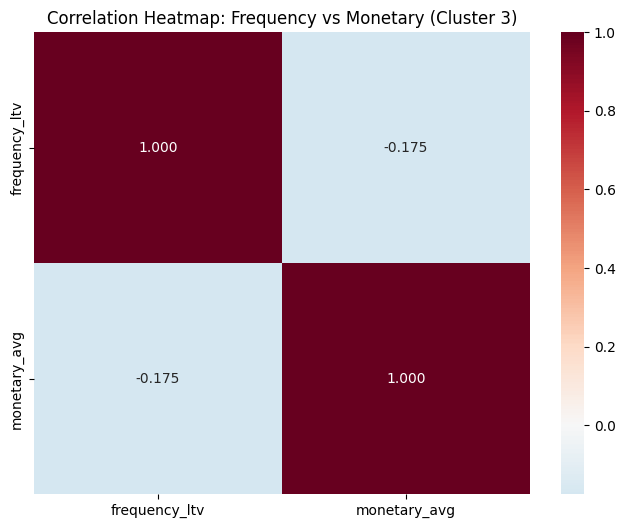

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.heatmap(correlation, annot=True, fmt='.3f', cmap='RdBu_r', center=0)
plt.title('Correlation Heatmap: Frequency vs Monetary (Cluster 3)')
plt.show()

In [14]:
vvip_customer = cluster_3.sort_values(by='predicted_clv', ascending=False)
vvip_customer

,customer_id,Recency,Frequency,Monetary,Cluster,first_purchase,T,recency_ltv,frequency_ltv,monetary_avg,predicted_clv
1286975,f4b02bd6ea956eee0c1f05897fc6a17b423a34cfd7d532...,7,2,1279.52,3,2020-09-15,8,1,1,639.760000,5348.688292
621162,76197f426400618a0b727733f06d39e2854bb1555491ef...,1,2,877.43,3,2020-09-20,3,2,1,438.715000,4116.809830
1127947,d6646c1dfd83db7236fa4049c20d4eb24527be8342c6b8...,3,2,870.49,3,2020-09-19,4,1,1,435.245000,3980.812263
776412,93acb0b36cf66c9ca4dbd8fe31f97811d19c7d73325d41...,9,2,933.99,3,2020-09-12,11,2,1,466.995000,3692.925080
1152433,db0dec50c1e91922576f6965e86adbd9cc5b3c11f3010d...,1,3,798.79,3,2020-09-12,11,10,2,266.263333,3685.521317
...,...,...,...,...,...,...,...,...,...,...,...
1346485,fffdfad0d0527fa55b97f0d2f2ae4b2e659de8345bfd73...,252,1,24.99,3,2020-01-15,252,0,0,24.990000,NaN
1346498,fffec7f7e9bc9270d49b39c870feba01d9367c53b31f54...,144,1,39.97,3,2020-05-02,144,0,0,39.970000,NaN
1346500,fffeec73fb0d1884cd99b8ace0044b94f72d671672cbb6...,166,1,26.98,3,2020-04-10,166,0,0,26.980000,NaN
1346506,ffff2d1849db66617499febae392fb5e9335ebf160de0e...,306,1,22.98,3,2019-11-22,306,0,0,22.980000,NaN


In [13]:
ltv_df[['frequency_ltv', 'monetary_avg']].corr()

,frequency_ltv,monetary_avg
frequency_ltv,1.000000,0.011105
monetary_avg,0.011105,1.000000


In [ ]:
# 재구매 고객만 대상으로 다시 확인
# 많이 사는 사람이 비싼 걸 사는 것도 아니고, 적게 사는 사람이 싼 걸 사는 것도 아니다
ltv_df[ltv_df['frequency_ltv'] > 0][['frequency_ltv', 'monetary_avg']].corr()

,frequency_ltv,monetary_avg
frequency_ltv,1.00000,0.00737
monetary_avg,0.00737,1.00000


In [15]:
# 모든 군집별 예상 가치(LTV) 평균 비교
comparison = ltv_df.groupby('Cluster')['predicted_clv'].agg(['count', 'mean', 'median', 'max'])
print(comparison.sort_values(by='mean', ascending=False))

          count         mean       median           max
Cluster                                                
2         25144  1650.836867  1466.759724  14577.044209
0        198455   493.494537   433.085563   5033.880748
3        535157   148.704170   116.910423   5348.688292
1        288609     5.736677     1.243187    516.821509


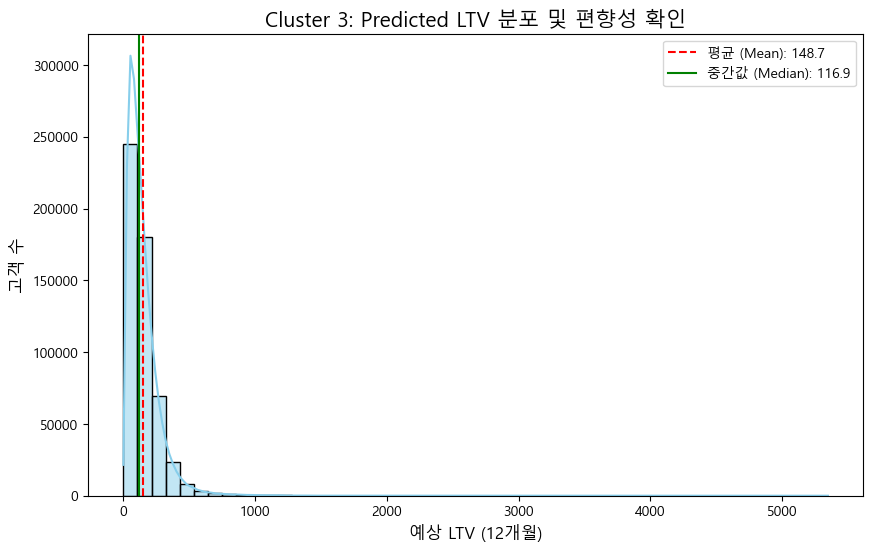

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 폰트 설정 (환경에 따라 'Malgun Gothic' 등으로 변경 필요)
plt.rcParams['font.family'] = 'Malgun Gothic'

# Cluster 3 데이터 필터링
c3_clv = ltv_df[ltv_df['Cluster'] == 3]['predicted_clv']

plt.figure(figsize=(10, 6))

# 히스토그램과 밀도 곡선
sns.histplot(c3_clv, kde=True, color='skyblue', bins=50)

# 평균(Mean)과 중간값(Median) 표시
plt.axvline(c3_clv.mean(), color='red', linestyle='--', label=f'평균 (Mean): {c3_clv.mean():.1f}')
plt.axvline(c3_clv.median(), color='green', linestyle='-', label=f'중간값 (Median): {c3_clv.median():.1f}')

# 그래프 제목 및 라벨
plt.title('Cluster 3: Predicted LTV 분포 및 편향성 확인', fontsize=15)
plt.xlabel('예상 LTV (12개월)', fontsize=12)
plt.ylabel('고객 수', fontsize=12)
plt.legend()

# 꼬리 부분이 너무 길어 앞부분이 안 보일 경우 x축 범위 제한 (필요시 사용)
# plt.xlim(0, c3_clv.quantile(0.99)) 

plt.show()

In [ ]:
==============================================================

In [8]:
# 1. Cluster 3 고객 아이디만 추출
c3_users = rfm[rfm['Cluster'] == 3]['customer_id']

# 2. 이들이 구매한 상품 정보 결합 (df는 원본 거래 데이터)
c3_data = df[df['customer_id'].isin(c3_users)]

# 3. 이들이 가장 많이 산 '카테고리'와 '상품명' Top 10
print("Cluster 3가 가장 선호하는 카테고리 Top 10")
print(c3_data['product_type_name'].value_counts().head(10))

print("Cluster 3가 가장 많이 산 구체적 상품명 Top 10")
print(c3_data['product_group_name'].value_counts().head(10))

# 4. 이들의 평균 연령대 확인
avg_age = c3_data['age'].mean()
print(f"Cluster 3의 평균 나이: {avg_age:.1f}세")

Cluster 3가 가장 선호하는 카테고리 Top 10
product_type_name
Trousers           1263458
Dress               901469
Sweater             813388
T-shirt             752566
Top                 492232
Bra                 476738
Vest top            475482
Bikini top          424052
Blouse              420578
Swimwear bottom     403524
Name: count, dtype: int64
Cluster 3가 가장 많이 산 구체적 상품명 Top 10
product_group_name
Garment Upper body    3865169
Garment Lower body    2160115
Garment Full body      998469
Swimwear               934491
Underwear              918706
Accessories            508079
Socks & Tights         254459
Shoes                  195840
Nightwear              107731
Unknown                 37656
Name: count, dtype: int64
Cluster 3의 평균 나이: 35.2세


In [ ]:
통계적 기법 왜 클러스터링 3을 타겟해야하는 이유를 
클러스터링3의 코호트

In [9]:
# 1. Cluster 3 고객 아이디만 추출
c3_users = rfm[rfm['Cluster'] == 3]['customer_id']

# 2. 이들이 구매한 상품 정보 결합 (df는 원본 거래 데이터)
c3_data = df[df['customer_id'].isin(c3_users)]

# 3. 이들이 가장 많이 산 '카테고리'와 '상품명' Top 10
print("Cluster 3가 가장 선호하는 카테고리 Top 10")
print(c3_data['garment_group_name'].value_counts().head(10))

print("Cluster 3가 가장 많이 산 구체적 상품명 Top 10")
print(c3_data['prod_name'].value_counts().head(10))

# 4. 이들의 평균 연령대 확인
avg_age = c3_data['age'].mean()
print(f"Cluster 3의 평균 나이: {avg_age:.1f}세")

Cluster 3가 가장 선호하는 카테고리 Top 10
garment_group_name
Jersey Fancy         1617661
Jersey Basic         1109177
Under-, Nightwear    1043894
Swimwear              922998
Trousers              907135
Blouses               737428
Knitwear              692791
Dresses Ladies        607733
Accessories           525435
Trousers Denim        373817
Name: count, dtype: int64
Cluster 3가 가장 많이 산 구체적 상품명 Top 10
prod_name
Jade HW Skinny Denim TRS       64426
Timeless Midrise Brief         53613
Luna skinny RW                 49762
Tilly (1)                      43117
Simple as That Triangle Top    34167
Cat Tee.                       33534
Tilda tank                     31126
Simple as that Cheeky Tanga    28476
Shake it in Balconette         28423
Skinny Ankle R.W Brooklyn      24998
Name: count, dtype: int64
Cluster 3의 평균 나이: 35.2세


In [ ]:
c3_data['product_type_name'].value_counts().head(10)

In [12]:
df.isna().sum()

t_dat                          0
customer_id                    0
article_id                     0
price                          0
sales_channel_id               0
prod_name                      0
product_type_name              0
product_group_name             0
colour_group_name              0
perceived_colour_value_name    0
department_name                0
garment_group_name             0
FN                             0
Active                         0
club_member_status             0
fashion_news_frequency         0
age                            0
age_group                      0
dtype: int64

In [ ]:
지지도 전체거리 중 a와b를 동시에 구매한 비율
신뢰도  a를 샀을때 b도 샀을 확률
향상도 a를 샀을때 b를 사는것이 그냥 b를 살때보다 얼마나 확률이 높은가

In [29]:
from mlxtend.frequent_patterns import fpgrowth
from mlxtend.frequent_patterns import association_rules
# apriori 대신 fpgrowth 사용 (속도가 훨씬 빠르고 메모리 사용량이 적음)
# 1. 한 전표(customer_id)당 구매한 상품 리스트를 원-핫 인코딩 형태로 변환
basket = (c3_data.groupby(['customer_id', 'product_type_name'])['product_type_name']
          .count().unstack().reset_index().fillna(0)
          .set_index('customer_id'))

# 2. 1 이상은 1로, 0은 0으로 변환 (구매 여부만 판단)
def encode_units(x):
    if x <= 0: return 0
    if x >= 1: return 1

basket_sets = basket.applymap(encode_units)

frequent_itemsets = fpgrowth(basket_sets, min_support=0.05, use_colnames=True)
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1)

rules.sort_values('lift', ascending=False)

# antecedents  이걸산사람이
# consequents  이것도 사더라
# antecedent support a의 인기(단독으로 구매한 비율)
# consequent support b의 인기(단독으로 구매한 비율)
# support 지지도 a와b를 동시에 구매한비율
# confidence a를 산 사람이 b도 살 확률
# lift 1보다 크면 유의미(연관성이 높다)
# leverage 0이면 독립,양수면 연관성있음
# conviction(확신성) 1이면관계없음,값이 커질수록 a를 샀는데 b를 안살확률이 낮음

C:\Users\dlcks\AppData\Local\Temp\ipykernel_4864\390660598.py:14: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  basket_sets = basket.applymap(encode_units)
c:\Users\dlcks\anaconda3\Lib\site-packages\mlxtend\frequent_patterns\fpcommon.py:175: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
2592,"(T-shirt, Bikini top)","(Vest top, Swimwear bottom)",0.106102,0.092246,0.051114,0.481744,5.222383,1.0,0.041326,1.751556,0.904484,0.347161,0.429079,0.517924
2597,"(Vest top, Swimwear bottom)","(T-shirt, Bikini top)",0.092246,0.106102,0.051114,0.554104,5.222383,1.0,0.041326,2.004722,0.890678,0.347161,0.501178,0.517924
2505,"(Top, Swimwear bottom)","(T-shirt, Bikini top)",0.093463,0.106102,0.051662,0.552755,5.209674,1.0,0.041745,1.998678,0.891358,0.349298,0.499669,0.519833
2500,"(T-shirt, Bikini top)","(Top, Swimwear bottom)",0.106102,0.093463,0.051662,0.486910,5.209674,1.0,0.041745,1.766819,0.903961,0.349298,0.434011,0.519833
2476,"(Top, Swimwear bottom)","(Sweater, Bikini top)",0.093463,0.112147,0.054429,0.582357,5.192796,1.0,0.043947,2.125867,0.890670,0.360023,0.529604,0.533845
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2154,(Trousers),(Swimwear bottom),0.521154,0.226983,0.125787,0.241362,1.063347,1.0,0.007494,1.018953,0.124411,0.202116,0.018601,0.397765
2174,"(Bikini top, Swimwear bottom)",(Trousers),0.199762,0.521154,0.109695,0.549126,1.053674,1.0,0.005588,1.062040,0.063656,0.179468,0.058416,0.379805
2175,(Trousers),"(Bikini top, Swimwear bottom)",0.521154,0.199762,0.109695,0.210484,1.053674,1.0,0.005588,1.013581,0.106380,0.179468,0.013399,0.379805
1975,(Bikini top),(Trousers),0.229287,0.521154,0.125034,0.545317,1.046366,1.0,0.005540,1.053144,0.057494,0.199924,0.050462,0.392617


In [ ]:
rules

In [ ]:
frozenset({'T-shirt', 'Bikini top'})

In [30]:
# 1. 대상 상품 설정 (개별 문자열로 분리)
item_A1 = 'T-shirt'
item_A2 = 'Bikini top'
item_B1 = 'Vest top'
item_B2 = 'Swimwear bottom'

# 2. 개별 컬럼에 접근하여 조건 생성
# A1도 샀고(1) AND A2도 산(1) 고객
cond_A = (basket_sets[item_A1] == 1) & (basket_sets[item_A2] == 1)

# B1도 안 샀고(0) AND B2도 안 산(0) 고객
cond_B = (basket_sets[item_B1] == 0) & (basket_sets[item_B2] == 0)

# 3. 최종 고객 추출
target_customers = basket_sets[cond_A & cond_B].index

print(f"조건에 맞는 고객 수: {len(target_customers)}명")
print(target_customers.tolist()[:10])

조건에 맞는 고객 수: 4525명
['001ea5b25c75e6490705b22abb670e08007967c631a4c5a9c1473857d2fa41e2', '0020339c4691ddc25e204615ded43854a9fdefbfc14beb561b1e378fda391658', '002745d97a5ab43d3106e405a9872c081f96fad28cfa13ba2f360113fa0751f4', '004b0a6e7c28a52588cb3410d4fc594bd4f1d060d9f1823fbd7582fcc7efc307', '0073e18573581324d654ca9e49aca533e9954cd59172369ef403b9e030d8e9c0', '0084f27bbe226020ec3a25afdd7c9dca10011b7f5b929e4353234faa313b4ffa', '00871d34d93083c1f6d0e1f8934f3177ca878858d4660b7dfff4c1da1fb59952', '009af358aa4305e6b928451c580d8a14ca6e35c2205c1e99536ec43e0bd700aa', '009d8f2fa8187201f56d5c792eab142aeb39af3c7cfffcc40fc02a1dd4adf1ff', '00cc3ef6ba7eb7c651781ba0ce78af2c4e8fba4ce90a2bc962bc27f4ab3c6065']


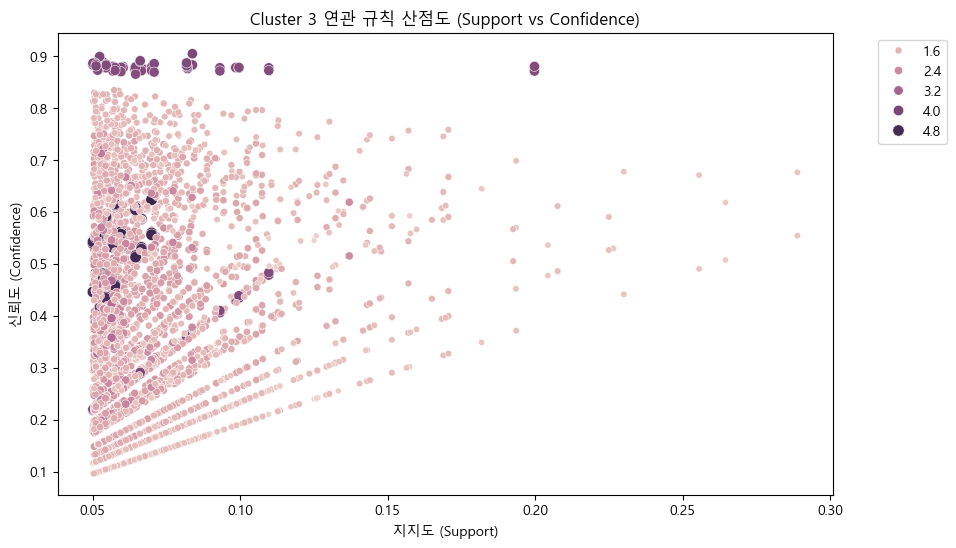

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 깨짐 방지 (필요 시)
plt.rcParams['font.family'] = 'Malgun Gothic' 

plt.figure(figsize=(10, 6))
sns.scatterplot(x='support', y='confidence', hue='lift', size='lift', data=rules)
plt.title('Cluster 3 연관 규칙 산점도 (Support vs Confidence)')
plt.xlabel('지지도 (Support)')
plt.ylabel('신뢰도 (Confidence)')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2)
plt.show()

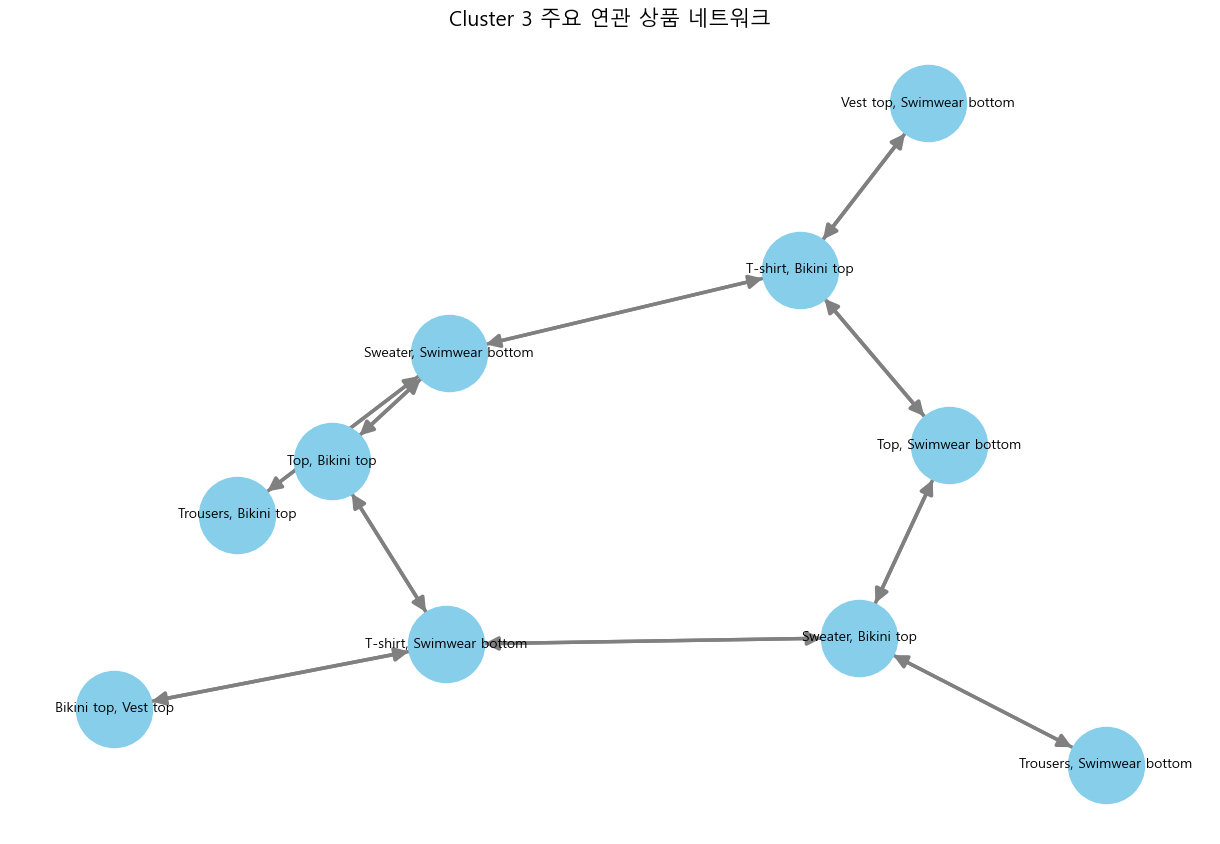

In [13]:
import networkx as nx

# 상위 20개 규칙만 추출 (너무 많으면 그래프가 복잡해짐)
sub_rules = rules.sort_values('lift', ascending=False).head(20)

G = nx.DiGraph()

# 노드와 에지 추가
for i, row in sub_rules.iterrows():
    # frozenset을 문자열로 변환
    ant = ', '.join(list(row['antecedents']))
    con = ', '.join(list(row['consequents']))
    G.add_edge(ant, con, weight=row['lift'])

# 그래프 그리기
plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G, k=1)  # 노드 간의 간격 조절
nx.draw(G, pos, with_labels=True, node_size=3000, node_color="skyblue", 
        font_size=10, font_family='Malgun Gothic', edge_color="gray", 
        arrowsize=20, width=[d['weight']/2 for u, v, d in G.edges(data=True)])

plt.title('Cluster 3 주요 연관 상품 네트워크', size=15)
plt.show()

In [14]:
from mlxtend.frequent_patterns import fpgrowth
from mlxtend.frequent_patterns import association_rules

# 1. 한 전표(customer_id)당 구매한 상품 리스트를 원-핫 인코딩 형태로 변환
baskets = (c3_data.groupby(['customer_id', 'colour_group_name'])['colour_group_name']
          .count().unstack().reset_index().fillna(0)
          .set_index('customer_id'))

# 2. 1 이상은 1로, 0은 0으로 변환 (구매 여부만 판단)
def encode_units(x):
    if x <= 0: return 0
    if x >= 1: return 1

basket_sets = baskets.applymap(encode_units)

frequent_itemsets = fpgrowth(basket_sets, min_support=0.05, use_colnames=True)
result = association_rules(frequent_itemsets, metric="lift", min_threshold=1)

# 결과 확인 (가장 연관성이 높은 순서대로)
result .sort_values('lift', ascending=False)

C:\Users\dlcks\AppData\Local\Temp\ipykernel_4864\4059224079.py:14: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  basket_sets = baskets.applymap(encode_units)
c:\Users\dlcks\anaconda3\Lib\site-packages\mlxtend\frequent_patterns\fpcommon.py:175: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
1520,"(Light Blue, Dark Blue)","(Black, White, Blue)",0.142909,0.181182,0.063125,0.441712,2.437954,1.0,0.037232,1.466660,0.688165,0.241888,0.318179,0.395059
1505,"(Black, White, Blue)","(Light Blue, Dark Blue)",0.181182,0.142909,0.063125,0.348405,2.437954,1.0,0.037232,1.315374,0.720331,0.241888,0.239760,0.395059
1506,"(Black, Light Blue, Dark Blue)","(White, Blue)",0.136694,0.189879,0.063125,0.461793,2.432041,1.0,0.037169,1.505223,0.682056,0.239609,0.335646,0.397120
1519,"(White, Blue)","(Black, Light Blue, Dark Blue)",0.189879,0.136694,0.063125,0.332446,2.432041,1.0,0.037169,1.293238,0.726833,0.239609,0.226747,0.397120
1493,"(Light Blue, Dark Blue)","(White, Blue)",0.142909,0.189879,0.064538,0.451600,2.378361,1.0,0.037402,1.477246,0.676174,0.240588,0.323065,0.395745
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2408,(Black),(Blue),0.836870,0.269482,0.245055,0.292823,1.086615,1.0,0.019534,1.033006,0.488636,0.284518,0.031952,0.601090
1625,(Beige),(Black),0.238579,0.836870,0.216689,0.908249,1.085292,1.0,0.017029,1.777953,0.103213,0.252328,0.437555,0.583588
1624,(Black),(Beige),0.836870,0.238579,0.216689,0.258928,1.085292,1.0,0.017029,1.027459,0.481757,0.252328,0.026725,0.583588
2538,(Black),(White),0.836870,0.545272,0.491674,0.587515,1.077471,1.0,0.035352,1.102410,0.440759,0.552152,0.092897,0.744609


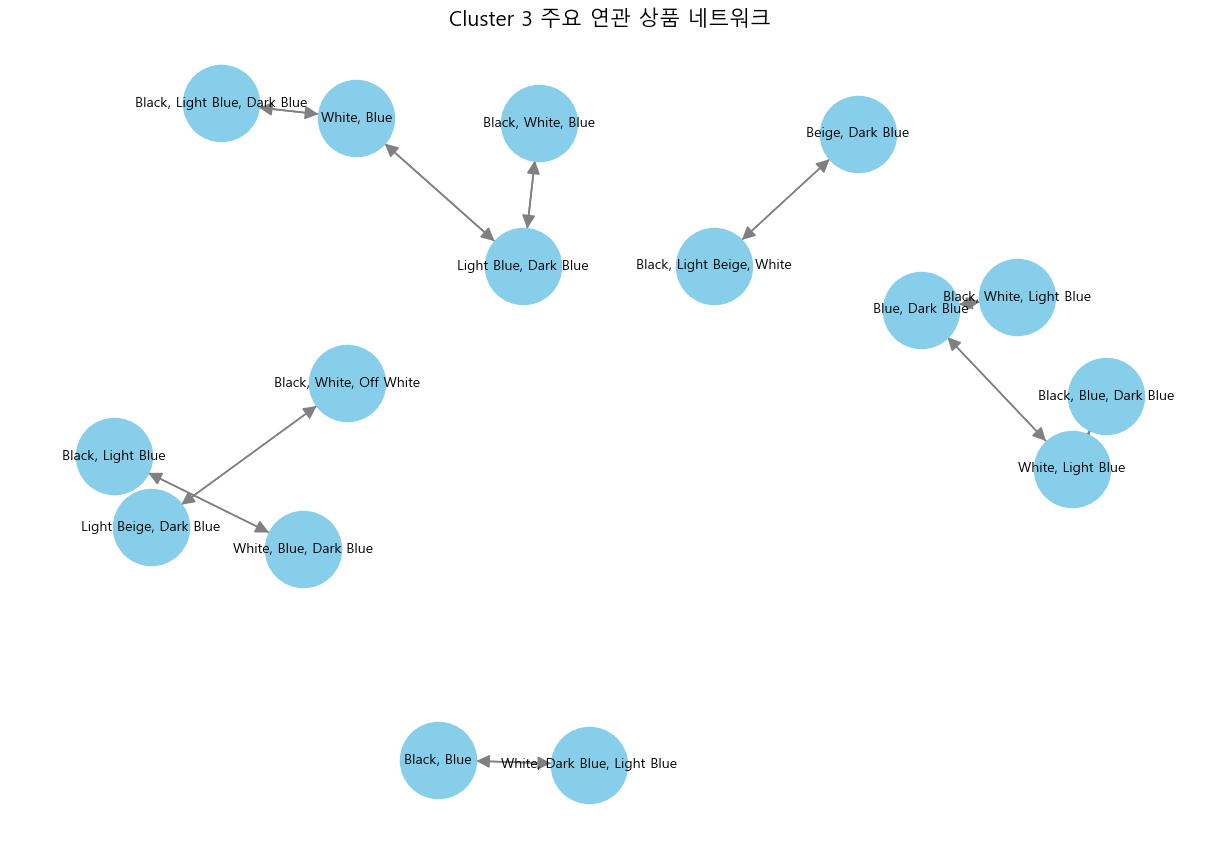

In [17]:
import networkx as nx
import matplotlib.pyplot as plt 

# 한글 깨짐 방지 (Windows 기준)
plt.rcParams['font.family'] = 'Malgun Gothic' 
plt.rcParams['axes.unicode_minus'] = False
# 상위 20개 규칙만 추출 (너무 많으면 그래프가 복잡해짐)
sub_rules = result.sort_values('lift', ascending=False).head(20)

G = nx.DiGraph()

# 노드와 에지 추가
for i, row in sub_rules.iterrows():
    # frozenset을 문자열로 변환
    ant = ', '.join(list(row['antecedents']))
    con = ', '.join(list(row['consequents']))
    G.add_edge(ant, con, weight=row['lift'])

# 그래프 그리기
plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G, k=1)  # 노드 간의 간격 조절
nx.draw(G, pos, with_labels=True, node_size=3000, node_color="skyblue", 
        font_size=10, font_family='Malgun Gothic', edge_color="gray", 
        arrowsize=20, width=[d['weight']/2 for u, v, d in G.edges(data=True)])

plt.title('Cluster 3 주요 연관 상품 네트워크', size=15)
plt.show()

In [20]:
# 특정옷을 사는데 어떤 색상을 같이 샀는가
import pandas as pd
from mlxtend.frequent_patterns import fpgrowth, association_rules

# 1. '옷 종류' 데이터와 '색상' 데이터를 각각 원-핫 인코딩하여 옆으로 합치기
# 고객별로 어떤 옷 종류를 샀는지 체크
garment_basket = c3_data.groupby(['customer_id', 'garment_group_name'])['garment_group_name'].count().unstack().fillna(0)

# 고객별로 어떤 색상을 샀는지 체크
color_basket = c3_data.groupby(['customer_id', 'colour_group_name'])['colour_group_name'].count().unstack().fillna(0)

# 두 테이블을 옆으로 합침 (고객 ID 기준)
combined_basket = pd.concat([garment_basket, color_basket], axis=1)

# 2. 샀으면 1, 안 샀으면 0으로 변환
basket_sets = combined_basket.applymap(lambda x: 1 if x > 0 else 0)

# 3. 연관 규칙 분석 실행 (FP-Growth)
frequent_itemsets = fpgrowth(basket_sets, min_support=0.03, use_colnames=True)
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1)

# 4. 결과 필터링 (왼쪽에는 옷 종류가 있고, 오른쪽에는 색상이 있는 경우만 찾기)
# 이 과정이 없으면 '색상-색상'이나 '옷-옷' 관계도 섞여 나옵니다.
filtered_rules = rules[
    rules['antecedents'].apply(lambda x: any(item in garment_basket.columns for item in x)) &
    rules['consequents'].apply(lambda x: any(item in color_basket.columns for item in x))
]

filtered_rules.sort_values('lift', ascending=False).head(10)

C:\Users\dlcks\AppData\Local\Temp\ipykernel_4864\1090481200.py:16: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  basket_sets = combined_basket.applymap(lambda x: 1 if x > 0 else 0)
c:\Users\dlcks\anaconda3\Lib\site-packages\mlxtend\frequent_patterns\fpcommon.py:175: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
441950,"(Trousers Denim, Jersey Basic, Jersey Fancy, T...","(Black, Light Blue, Blue, Dark Blue)",0.093928,0.075283,0.030345,0.323068,4.291361,1.0,0.023274,1.366040,0.846482,0.218520,0.267957,0.363073
447815,"(Trousers Denim, Blouses, Jersey Fancy, Trousers)","(Black, White, Blue, Light Blue)",0.084428,0.087092,0.031276,0.370453,4.253586,1.0,0.023924,1.450103,0.835438,0.223016,0.310394,0.364787
442012,"(Trousers Denim, Jersey Basic, Trousers)","(Black, Jersey Fancy, Light Blue, Dark Blue, B...",0.106174,0.067338,0.030345,0.285806,4.244371,1.0,0.023196,1.305894,0.855193,0.211957,0.234241,0.368223
447854,"(Blouses, Light Blue, Blue, Black)","(Trousers Denim, Jersey Fancy, White, Trousers)",0.071209,0.103875,0.031276,0.439223,4.228386,1.0,0.023880,1.598005,0.822040,0.217489,0.374220,0.370160
447835,"(Trousers Denim, Jersey Fancy, White, Trousers)","(Blouses, Light Blue, Blue, Black)",0.103875,0.071209,0.031276,0.301098,4.228386,1.0,0.023880,1.328929,0.852005,0.217489,0.247514,0.370160
440561,"(Trousers Denim, Jersey Fancy, White, Trousers)","(Black, Light Blue, Blue, Dark Blue)",0.103875,0.075283,0.033059,0.318259,4.227489,1.0,0.025239,1.356405,0.851949,0.226279,0.262757,0.378694
281745,"(Trousers Denim, Blouses, Jersey Basic, Trousers)","(Black, Jersey Fancy, White, Dark Blue, Blue)",0.069704,0.109365,0.032175,0.461589,4.220618,1.0,0.024551,1.654191,0.820242,0.219032,0.395475,0.377892
441936,"(Trousers Denim, Black, Jersey Basic, Trousers)","(Jersey Fancy, Light Blue, Blue, Dark Blue)",0.104853,0.068719,0.030345,0.289405,4.211431,1.0,0.023140,1.310565,0.851873,0.211866,0.236970,0.365493
441997,"(Jersey Fancy, Light Blue, Blue, Dark Blue)","(Trousers Denim, Black, Jersey Basic, Trousers)",0.068719,0.104853,0.030345,0.441582,4.211431,1.0,0.023140,1.603006,0.818819,0.211866,0.376172,0.365493
295968,"(Trousers Denim, Jersey Basic, Jersey Fancy, T...","(Black, White, Knitwear, Dark Blue, Blue)",0.093928,0.080144,0.031616,0.336595,4.199871,1.0,0.024088,1.386567,0.840879,0.221932,0.278794,0.365539


C:\Users\dlcks\AppData\Local\Temp\ipykernel_4864\2937857378.py:12: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  basket_sets = combined_basket.applymap(lambda x: 1 if x > 0 else 0)
c:\Users\dlcks\anaconda3\Lib\site-packages\mlxtend\frequent_patterns\fpcommon.py:175: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


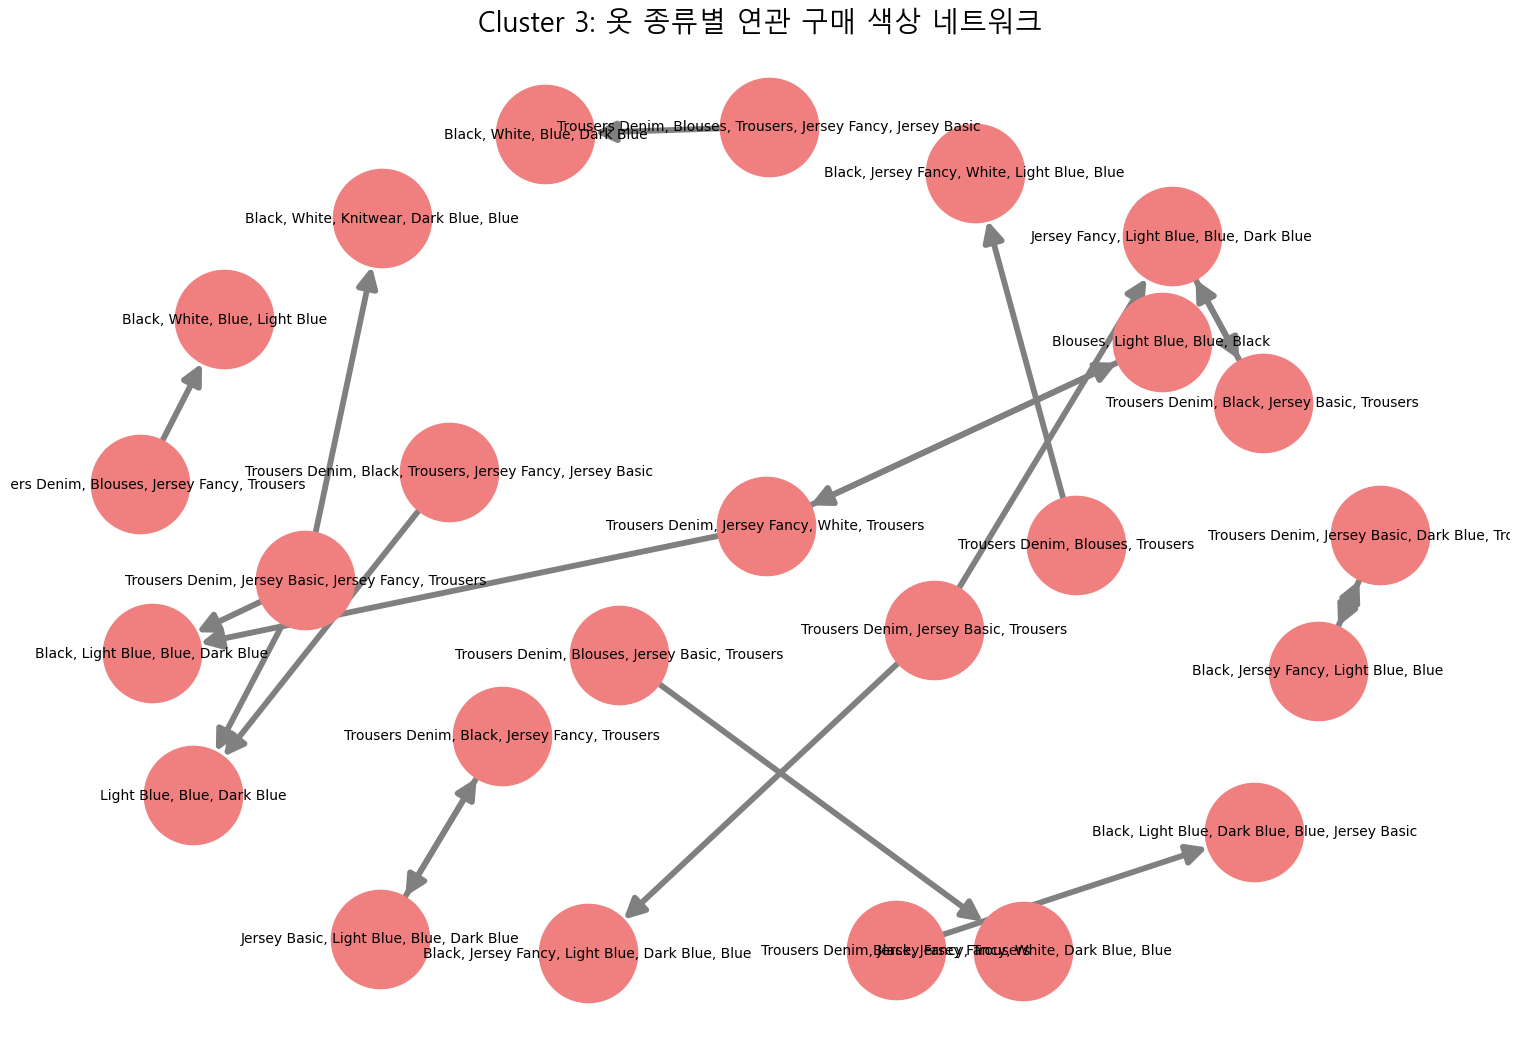

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from mlxtend.frequent_patterns import fpgrowth, association_rules

# 1. 데이터 준비: 옷 종류 열과 색상 열을 각각 만들어서 옆으로 합치기
garment_basket = c3_data.groupby(['customer_id', 'garment_group_name'])['garment_group_name'].count().unstack().fillna(0)
color_basket = c3_data.groupby(['customer_id', 'colour_group_name'])['colour_group_name'].count().unstack().fillna(0)

# 두 테이블 결합 (고객 한 명이 산 옷 종류와 색상이 한 행에 나열됨)
combined_basket = pd.concat([garment_basket, color_basket], axis=1)
basket_sets = combined_basket.applymap(lambda x: 1 if x > 0 else 0)

# 2. 연관 규칙 분석 (메모리 효율을 위해 fpgrowth 사용)
frequent_itemsets = fpgrowth(basket_sets, min_support=0.03, use_colnames=True)
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1)

# 3. 시각화용 데이터 필터링 (원인: 옷 종류 -> 결과: 색상 인 경우만 추출)
# 이 필터를 거쳐야 '검정색->하얀색' 같은 결과가 빠지고 '상의->검정색' 같은 결과만 남습니다.
viz_rules = rules[
    rules['antecedents'].apply(lambda x: any(item in garment_basket.columns for item in x)) &
    rules['consequents'].apply(lambda x: any(item in color_basket.columns for item in x))
].sort_values('lift', ascending=False).head(20)

# 4. 네트워크 그래프 시각화
G = nx.DiGraph()

for i, row in viz_rules.iterrows():
    ant = ', '.join(list(row['antecedents']))
    con = ', '.join(list(row['consequents']))
    G.add_edge(ant, con, weight=row['lift'])

plt.figure(figsize=(15, 10))
# 한글 폰트 설정 (Windows: Malgun Gothic, Mac: AppleGothic)
plt.rcParams['font.family'] = 'Malgun Gothic' 

pos = nx.spring_layout(G, k=1.5) # 노드 간격을 조금 더 넓게 설정
nx.draw(G, pos, with_labels=True, 
        node_size=5000, 
        node_color="lightcoral", # 색상 구분을 위해 변경
        font_size=10, 
        edge_color="gray", 
        arrowsize=30, 
        width=[d['weight'] for u, v, d in G.edges(data=True)])

plt.title('Cluster 3: 옷 종류별 연관 구매 색상 네트워크', size=20)
plt.show()

In [ ]:
이탈모델 추천모델링 배치전략